<a href="https://colab.research.google.com/github/thinus283-ux/LR/blob/main/Cosmology_solver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== ΛCDM BACKGROUND COSMOLOGY RESULTS (z=0) ===
Ω_m,0              = 0.315
w0                 = -1.0
Acceleration onset at z ≈ 0.629
q(z=0)             = -0.5269   (negative = accelerating)
H(z=0)/H0          = 1.0003  ✓
Ω_m(z=0)           = 0.3154
Ω_DE(z=0)          = 0.6846


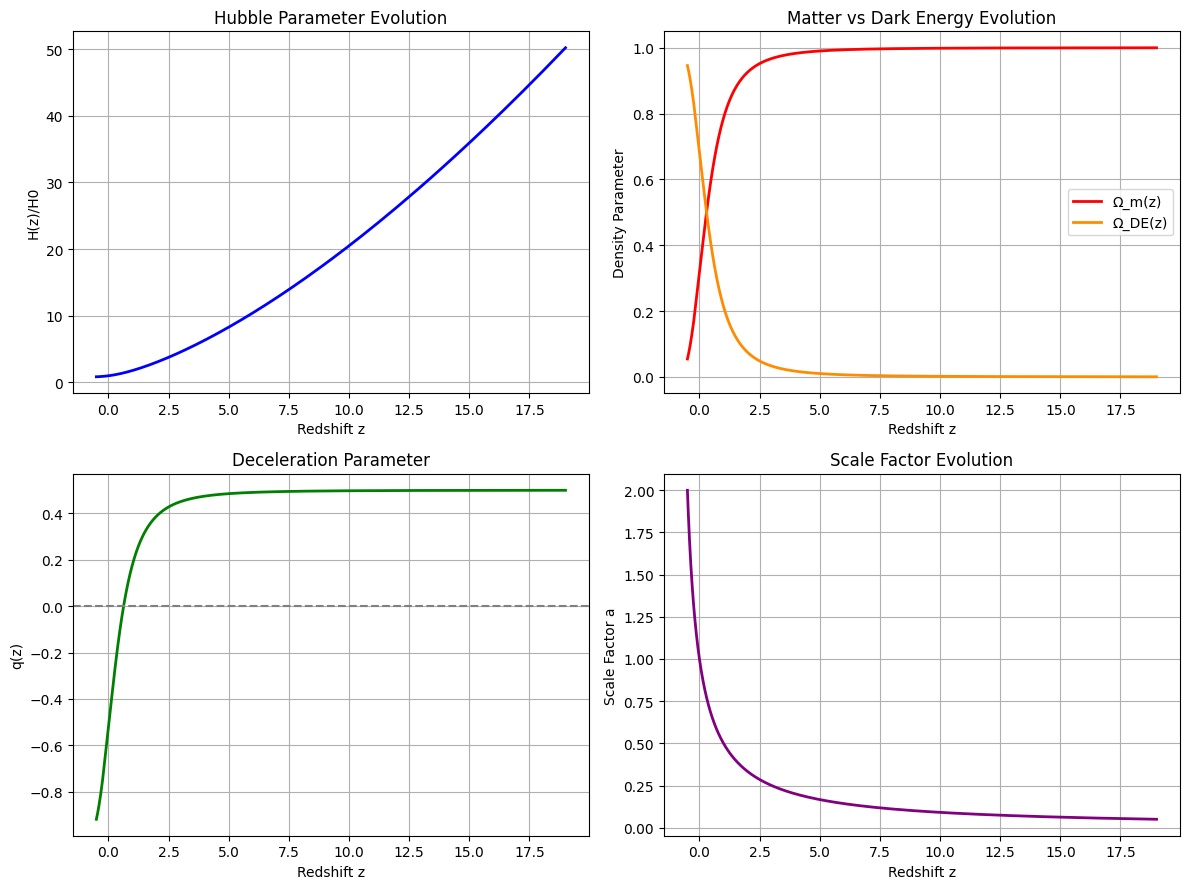

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# ================================================
# ΛCDM Background Cosmology Model
# ================================================

Om0 = 0.315          # Matter density parameter today
w0  = -1.0           # Dark energy equation of state
z_claim = 0.67       # Claimed transition redshift (for reference)

# Scale factor array
a = np.linspace(0.05, 2.0, 800)
z = 1/a - 1

# Hubble parameter squared (normalized)
E2 = Om0 * a**(-3) + (1 - Om0) * a**(-3*(1 + w0))
E = np.sqrt(E2)

# Density parameters as function of scale factor
Om_a = Om0 * a**(-3) / E2
Ode_a = (1 - Om0) * a**(-3*(1 + w0)) / E2

# Deceleration parameter q(a)
q = 0.5 * Om_a - Ode_a

# ================================================
# Key Results at z=0 (today)
# ================================================
idx0 = np.argmin(np.abs(a - 1.0))

print("=== ΛCDM BACKGROUND COSMOLOGY RESULTS (z=0) ===")
print(f"Ω_m,0              = {Om0}")
print(f"w0                 = {w0}")
print(f"Acceleration onset at z ≈ {z[np.argmin(np.abs(q))]:.3f}")
print(f"q(z=0)             = {q[idx0]:.4f}   (negative = accelerating)")
print(f"H(z=0)/H0          = {E[idx0]:.4f}  ✓")
print(f"Ω_m(z=0)           = {Om_a[idx0]:.4f}")
print(f"Ω_DE(z=0)          = {Ode_a[idx0]:.4f}")

# ================================================
# Plotting
# ================================================
fig, axs = plt.subplots(2, 2, figsize=(12, 9))

# 1. Hubble evolution
axs[0,0].plot(z, E, 'b-', linewidth=2)
axs[0,0].set_xlabel('Redshift z')
axs[0,0].set_ylabel('H(z)/H0')
axs[0,0].set_title('Hubble Parameter Evolution')
axs[0,0].grid(True)

# 2. Density parameters
axs[0,1].plot(z, Om_a, 'r-', label='Ω_m(z)', linewidth=2)
axs[0,1].plot(z, Ode_a, 'darkorange', label='Ω_DE(z)', linewidth=2)
axs[0,1].set_xlabel('Redshift z')
axs[0,1].set_ylabel('Density Parameter')
axs[0,1].set_title('Matter vs Dark Energy Evolution')
axs[0,1].legend()
axs[0,1].grid(True)

# 3. Deceleration parameter q(z)
axs[1,0].plot(z, q, 'g-', linewidth=2)
axs[1,0].axhline(0, color='gray', linestyle='--')
axs[1,0].set_xlabel('Redshift z')
axs[1,0].set_ylabel('q(z)')
axs[1,0].set_title('Deceleration Parameter')
axs[1,0].grid(True)

# 4. Scale factor vs redshift
axs[1,1].plot(z, a, 'purple', linewidth=2)
axs[1,1].set_xlabel('Redshift z')
axs[1,1].set_ylabel('Scale Factor a')
axs[1,1].set_title('Scale Factor Evolution')
axs[1,1].grid(True)

plt.tight_layout()
plt.show()